<a href="https://colab.research.google.com/github/aarohigorle2005/Data_Science_Lab/blob/main/Experiment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Columns:
 Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Model Performance:
MSE: 31.45404766495083
R² Score: 0.6270849941673196

Feature Importance:
     Feature  Coefficient
5        RM     4.258091
3      CHAS     1.983837
8       RAD     0.235588
1      

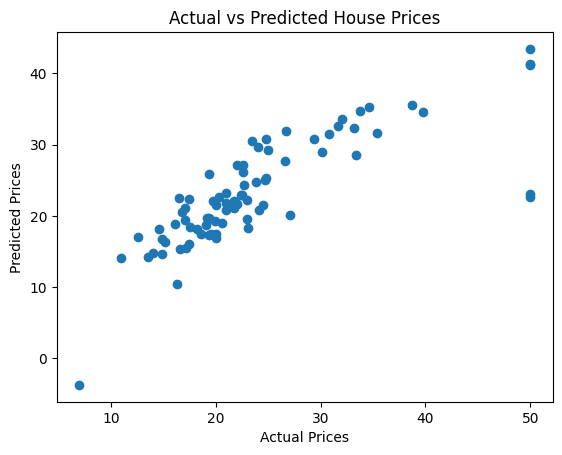


Sample Input:
       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE   DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.09    1  296     15.3   

       B  LSTAT  
0  396.9   4.98  
Predicted Price: 29.66737036637976


In [6]:
# Experiment 7: Linear Regression Model for House Price Prediction

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Download Dataset from Kaggle

dataset_path = "boston-housing-dataset"

if not os.path.exists(dataset_path):
    os.system("kaggle datasets download -d altavish/boston-housing-dataset")

    with zipfile.ZipFile("boston-housing-dataset.zip", 'r') as zip_ref:
        zip_ref.extractall(dataset_path)

# 2. Load Dataset
# Find CSV file automatically
for file in os.listdir(dataset_path):
    if file.endswith(".csv"):
        csv_path = os.path.join(dataset_path, file)
        break

df = pd.read_csv(csv_path)

print("First 5 rows:\n", df.head())
print("\nColumns:\n", df.columns)

# 3. Preprocessing
df = df.dropna()

X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
print("\nModel Performance:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# 8. Feature Importance
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance:\n", coeff_df)

# 9. Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# 10. Predict Sample
sample = X.iloc[[0]]   # correct format
prediction = model.predict(sample)

print("\nSample Input:\n", sample)
print("Predicted Price:", prediction[0])